# **Predicting on Streaming Data using Machine Learning**

To showcase my grasp of machine learning with PySpark, I'll walk through a couple of key scenarios. First, under the umbrella of _**Fitting Your Model**_, I'll demonstrate the process of reading in a static dataset (our 'batch'), performing initial summarization, transforming it into a suitable format, and constructing a machine learning pipeline for training and evaluation. Then, shifting gears to _**Modeling on Streaming**_, I'll tackle a similar dataset but ingest it incrementally. As new data arrives in the Jupyter environment, I'll show how to update predictions in near real-time.

### Fitting Your Model

##### Setting up the Environemnt, reading in the data, conversion to workable formatting.

The initial step involves importing the necessary Python modules for the subsequent tasks. Consistent with practices often employed in authoring RMarkdown documents, I have chosen to consolidate all module loading in a dedicated section at the beginning of this notebook. This centralized arrangement facilitates efficient management and debugging, should any issues arise during processing. As the analysis progresses, any additional required modules will be imported into this designated section as needed.

In [1]:
# seaborn install for a heatmap used in the summary section. 
!pip install seaborn

# Code Chunk handles loading the modules required for this assignment orderd by top-level packages, sub-packages, and submodules.
import os
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from pyspark import SparkContext
from pyspark.sql import SparkSession, Row
from pyspark.sql.types import DoubleType, StringType, StructType, StructField, LongType
from pyspark.sql.functions import col, round, count, avg, stddev, when
from pyspark.ml import Pipeline
from pyspark.ml.feature import Binarizer, OneHotEncoder, StringIndexer, PCA, VectorAssembler
from pyspark.ml.regression import LinearRegression
from pyspark.ml.tuning import CrossValidator, ParamGridBuilder
from pyspark.ml.evaluation import RegressionEvaluator

Defaulting to user installation because normal site-packages is not writeable


Now I can read-in the power_ml_data.csv file from a URL using `pandas`.  A snapshot of the pandas dataframe is made available just to see what we are working with.

In [2]:
# Code Chunk handles the "reading in" of the ML data into the ipynb environment
ml_df = pd.read_csv('https://www4.stat.ncsu.edu/~online/datasets/power_ml_data.csv')

# Brief sample of how the data appears after being read in raw.
ml_df.head(3)

,Temperature,Humidity,Wind_Speed,General_Diffuse_Flows,Diffuse_Flows,Power_Zone_1,Power_Zone_2,Power_Zone_3,Month,Hour
0,6.559,73.8,0.083,0.051,0.119,34055.69620,16128.87538,20240.96386,1,0
1,6.414,74.5,0.083,0.070,0.085,29814.68354,19375.07599,20131.08434,1,0
2,6.313,74.5,0.080,0.062,0.100,29128.10127,19006.68693,19668.43373,1,0


Next, conversion of the pandas dataframe to a spark dataframe. First, we have to initialize a spark session to use a spark dataframe.  The `appName()` lavels the spark application for downstream tracking of jobs; meanwhile, the `getOrCreate()` does that--retrieves it if it exists and creates a new one if it does not.  `createDataFrame`--self-explanitory.  The `createOrReplaceTempView()` is called so that it takes the `spark_df` object and gives it a TempView which is then needed so we can run SQL queries against it.

In [3]:
# Begins a Spark session.
spark = SparkSession.builder.appName("PandasToPySpark").getOrCreate()

# I was receiving some warnings when running a LinearRegression() method so this part silences those warnings. 
# REF:  https://spark.apache.org/docs/latest/api/python/reference/api/pyspark.SparkContext.setLogLevel.html
sc = spark.sparkContext
sc.setLogLevel("ERROR")

# Conversion to Spark DataFrame
spark_df = spark.createDataFrame(ml_df)

# Register the PySpark DataFrame as a temporary SQL table
# REF:  https://spark.apache.org/docs/latest/api/python/reference/pyspark.sql/api/pyspark.sql.DataFrame.createOrReplaceTempView.html
spark_df.createOrReplaceTempView("ml_table")

# Brief sample of how the spark dataframe appears after conversion. 
spark_df.show(3)

Setting default log level to "WARN".
To adjust logging level use sc.setLogLevel(newLevel). For SparkR, use setLogLevel(newLevel).
25/04/21 17:01:42 WARN NativeCodeLoader: Unable to load native-hadoop library for your platform... using builtin-java classes where applicable
25/04/21 17:01:42 WARN Utils: Service 'SparkUI' could not bind on port 4040. Attempting port 4041.
25/04/21 17:01:42 WARN Utils: Service 'SparkUI' could not bind on port 4041. Attempting port 4042.
25/04/21 17:01:42 WARN Utils: Service 'SparkUI' could not bind on port 4042. Attempting port 4043.


+-----------+--------+----------+---------------------+-------------+------------+------------+------------+-----+----+
|Temperature|Humidity|Wind_Speed|General_Diffuse_Flows|Diffuse_Flows|Power_Zone_1|Power_Zone_2|Power_Zone_3|Month|Hour|
+-----------+--------+----------+---------------------+-------------+------------+------------+------------+-----+----+
|      6.559|    73.8|     0.083|                0.051|        0.119|  34055.6962| 16128.87538| 20240.96386|    1|   0|
|      6.414|    74.5|     0.083|                 0.07|        0.085| 29814.68354| 19375.07599| 20131.08434|    1|   0|
|      6.313|    74.5|      0.08|                0.062|          0.1| 29128.10127| 19006.68693| 19668.43373|    1|   0|
+-----------+--------+----------+---------------------+-------------+------------+------------+------------+-----+----+
only showing top 3 rows



##### Summarize the Data

With the data ready to use in this notebook the next move is to look at the summaries of this data.  As is typically expected in an exploratory data analysis, we would want a high level view of how our data looks, how it is shaped, how it varies and how the data interacts among its features.

In [4]:
# First, computing the median since it stands alone from the summary() PySpark method used to find the rest of the summary values.
# I will declare the columns I want to take the median for, then compute the median for each.  Note that Month/Hour are going to 
# hold NaN values because it does not make sense to take the median of time-related values.
numeric_cols = ["Temperature", "Humidity", "Wind_Speed", "General_Diffuse_Flows", 
                "Diffuse_Flows", "Power_Zone_1", "Power_Zone_2", "Power_Zone_3"]
median_values = {col_name: float("{:.2f}".format(spark_df.approxQuantile(col_name, [0.5], 0.01)[0])) for col_name in numeric_cols}

# Take the median values and objectify them to a row that I can add to a table of summary values I am about to create
median_row = Row("median", *[str(median_values.get(c, "NA")) for c in spark_df.columns])

# Now create the summary table containing the remainder summary stats (means, standard deviations, min, max).  I am rounding all values to two places for readability. 
summary = spark_df.summary().select(
    "summary",
    *[round(col(c), 2).alias(c) for c in spark_df.columns if c != "summary"]
)

# Append median to table. 
summary = summary.union(spark.createDataFrame([median_row]))

# Show the summary table
summary.show(truncate=False)

+-------+-----------+--------+----------+---------------------+-------------+------------+------------+------------+-------+-------+
|summary|Temperature|Humidity|Wind_Speed|General_Diffuse_Flows|Diffuse_Flows|Power_Zone_1|Power_Zone_2|Power_Zone_3|Month  |Hour   |
+-------+-----------+--------+----------+---------------------+-------------+------------+------------+------------+-------+-------+
|count  |47174.0    |47174.0 |47174.0   |47174.0              |47174.0      |47174.0     |47174.0     |47174.0     |47174.0|47174.0|
|mean   |18.81      |68.29   |1.96      |182.53               |74.99        |32335.17    |21027.2     |17831.2     |6.51   |11.49  |
|stddev |5.81       |15.56   |2.35      |264.43               |124.26       |7130.01     |5199.79     |6622.59     |3.44   |6.92   |
|min    |3.25       |11.34   |0.05      |0.0                  |0.01         |13895.7     |8560.08     |5935.17     |1.0    |0.0    |
|25%    |14.42      |58.32   |0.08      |0.06                 |0.12  

We would want to examine a correlation matrix to see if there exists a relationship between the variables we are working with.  The code chunk below produces that output.  From what can be seen, there are a few observations to note:

* There is high correlation between power zones--likely the result of all three zones being powered by the same source.  
* Temperature is positively correlated with power demand
* Humidity is negatively correlated with power.  I would think that humidity generally means cloudiness, possible cooler days resulting in lower energy output (if solar) or lower demand (less cooling needs)
* There is some relationship between `Power_Zone_3` and `Wind_Speed`.  Possibility of some wind farm or geographical feature causing this.  We would need more information to explain this relationship. 

In [5]:
#Find the correlations between all variables where that makes sense to do
# List of numeric columns
numeric_cols = ["Temperature", "Humidity", "Wind_Speed", "General_Diffuse_Flows", 
                "Diffuse_Flows", "Power_Zone_1", "Power_Zone_2", "Power_Zone_3"]

# Compute correlations pairwise
# REF:  https://spark.apache.org/docs/latest/api/python/reference/pyspark.sql/api/pyspark.sql.DataFrame.corr.html
correlation_data = []
for col1 in numeric_cols:
    row_data = [col1]  # First element: column name
    for col2 in numeric_cols:
        correlation_value = spark_df.stat.corr(col1, col2)
        row_data.append(float(f"{correlation_value:.2f}"))  # Proper rounding
    correlation_data.append(Row(*row_data))  # Convert to Row object

# Create DataFrame from computed correlation values
correlation_df = spark.createDataFrame(correlation_data, ["Variable"] + numeric_cols)

# Show correlation matrix
correlation_df.show(truncate=False)

+---------------------+-----------+--------+----------+---------------------+-------------+------------+------------+------------+
|Variable             |Temperature|Humidity|Wind_Speed|General_Diffuse_Flows|Diffuse_Flows|Power_Zone_1|Power_Zone_2|Power_Zone_3|
+---------------------+-----------+--------+----------+---------------------+-------------+------------+------------+------------+
|Temperature          |1.0        |-0.46   |0.48      |0.46                 |0.2          |0.44        |0.38        |0.49        |
|Humidity             |-0.46      |1.0     |-0.14     |-0.47                |-0.26        |-0.29       |-0.3        |-0.23       |
|Wind_Speed           |0.48       |-0.14   |1.0       |0.13                 |-0.0         |0.17        |0.15        |0.28        |
|General_Diffuse_Flows|0.46       |-0.47   |0.13      |1.0                  |0.56         |0.19        |0.16        |0.06        |
|Diffuse_Flows        |0.2        |-0.26   |-0.0      |0.56                 |1.0   

As part of our assessment on the data, we might be interested in the frequency of observations in our data.  `Month` lowest count occur in month two and the highest in month three with a range of 469.  `Hour` lowest count is observed in hour fifteen and highest in hour six with a range of forty-five.  I do not see anything out of the ordinary here but we would be looking for outliers of observations.  From what I can tell, the data frequencies for `Month` and `Hour` are acceptable. 

In [6]:
# Contingency table for Month
month_ct = spark_df.groupBy("Month").agg(count("*").alias("Count")).orderBy("Month")
month_ct.show()

# Contingency table for Hour
hour_ct = spark_df.groupBy("Hour").agg(count("*").alias("Count")).orderBy("Hour")
hour_ct.show()

+-----+-----+
|Month|Count|
+-----+-----+
|    1| 4014|
|    2| 3588|
|    3| 4057|
|    4| 3893|
|    5| 3997|
|    6| 3913|
|    7| 4029|
|    8| 3999|
|    9| 3913|
|   10| 4026|
|   11| 3877|
|   12| 3868|
+-----+-----+

+----+-----+
|Hour|Count|
+----+-----+
|   0| 1950|
|   1| 1973|
|   2| 1973|
|   3| 1966|
|   4| 1986|
|   5| 1968|
|   6| 1992|
|   7| 1964|
|   8| 1957|
|   9| 1976|
|  10| 1955|
|  11| 1972|
|  12| 1979|
|  13| 1956|
|  14| 1971|
|  15| 1947|
|  16| 1950|
|  17| 1979|
|  18| 1955|
|  19| 1950|
+----+-----+
only showing top 20 rows



We might want to look at our data frequencies by `Month` and by `Hour` next.  This would show us areas in our data that have more representation than others.

In [7]:
# Compute the contingency table for Month and Hour
contingency_table = spark_df.groupBy("Month", "Hour").agg(count("*").alias("Count")).orderBy("Month", "Hour")

# Show the contingency table
contingency_table.show(truncate=False)

+-----+----+-----+
|Month|Hour|Count|
+-----+----+-----+
|1    |0   |161  |
|1    |1   |165  |
|1    |2   |168  |
|1    |3   |162  |
|1    |4   |167  |
|1    |5   |168  |
|1    |6   |168  |
|1    |7   |168  |
|1    |8   |172  |
|1    |9   |174  |
|1    |10  |164  |
|1    |11  |174  |
|1    |12  |170  |
|1    |13  |165  |
|1    |14  |167  |
|1    |15  |163  |
|1    |16  |169  |
|1    |17  |170  |
|1    |18  |168  |
|1    |19  |162  |
+-----+----+-----+
only showing top 20 rows



The two-way is somewhat lengthy and difficult to discern areas of over/under representation.  This is a heatmap of the two-way contingency table to help illustrate it better.  It shows observations with more data (red) and few data (blue) than usual.  The darker reds are scattered about with no patterns which is fine.  If you stare at this heatmap long enough, you might see that there are fewer observations in two regions; months 9-12 with hours 5-10, and a second region in months 1-5 with hours 14-20. The `Month` two definitely shows a pattern of fewer observations across the board.  I do not know if that is worth looking into or not but I would likely note this observation in any final report. 

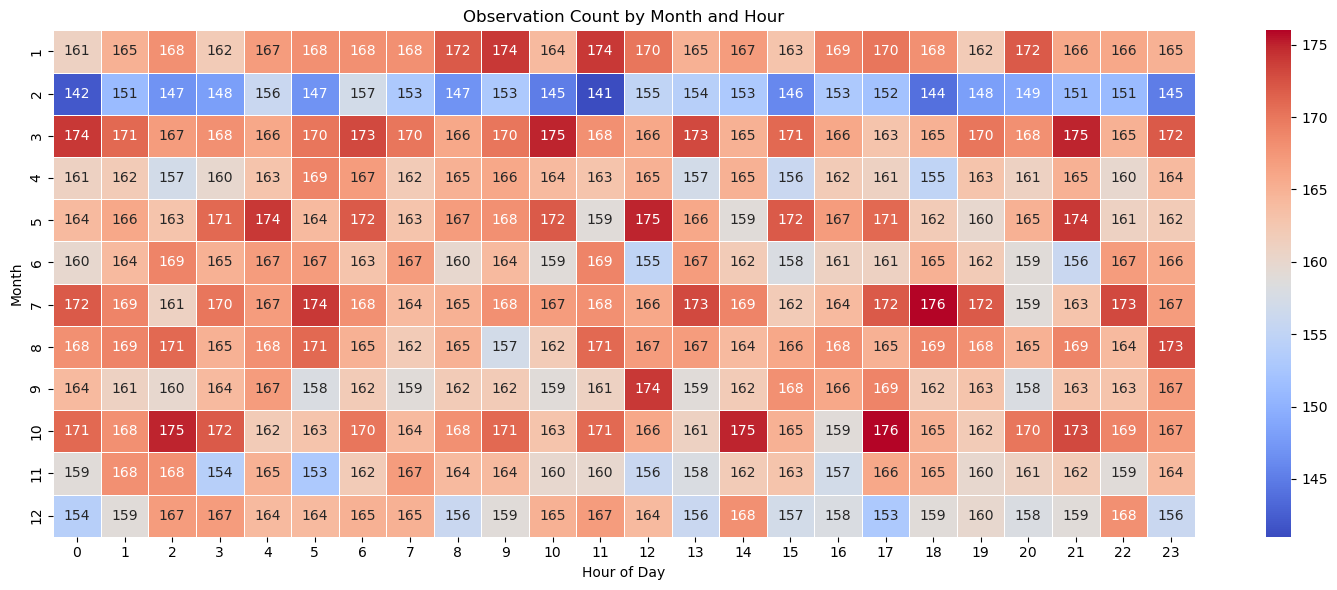

In [8]:
# Convert the PySpark contingency table back to Pandas to use with seaborn. 
# REF:  https://spark.apache.org/docs/latest/api/python/reference/pyspark.sql/api/pyspark.sql.DataFrame.toPandas.html
contingency_pd = contingency_table.toPandas()

# Pivot it into a matrix for a heatmap
# REF:  https://spark.apache.org/docs/latest/api/python/reference/pyspark.sql/api/pyspark.sql.GroupedData.pivot.html
heatmap_data = contingency_pd.pivot(index="Month", columns="Hour", values="Count")

# Plot the Heatmap
# REF:  https://seaborn.pydata.org/generated/seaborn.heatmap.html
plt.figure(figsize=(15, 6))
sns.heatmap(heatmap_data, annot=True, fmt="d", cmap="coolwarm", cbar=True, linewidths=0.5)
plt.title("Observation Count by Month and Hour")
plt.xlabel("Hour of Day")
plt.ylabel("Month")
plt.tight_layout()
plt.show()

Gathering summaries by month will help us understand seasonal average.  This next code block groups the data by month and obtains the averages for each of the numeric variables.  There are some seasonality elements we can observe.  Months five through nine have higher mean temperatures, higher mean wind speeds, and higher general diffuse flows on average.  All mean power zones show increased output during this time too, on average.  Hummidity stays fairly consistent on average withthe exception of month seven.  `Mean_diffuse_flows` does not follow the `general_diffuse_flows` pattern; showing spikes only during months five and six. 

In [9]:
# Group the data by Month and find the means of the numeric variables
# Compute mean values for each numeric column grouped by Month
mean_by_month = spark_df.groupBy("Month").agg(
    *[avg(col_name).alias(f"Mean_{col_name}") for col_name in ["Temperature", "Humidity", "Wind_Speed",
                                                               "General_Diffuse_Flows", "Diffuse_Flows",
                                                               "Power_Zone_1", "Power_Zone_2", "Power_Zone_3"]])

# Round all numeric columns to 3 decimal places
rounded_means = mean_by_month.select(
    "Month",  # Keep Month column unchanged
    *[round(col(c), 3).alias(c) for c in mean_by_month.columns if c != "Month"])

# Show the rounded table
rounded_means.show(truncate=False)

+-----+----------------+-------------+---------------+--------------------------+------------------+-----------------+-----------------+-----------------+
|Month|Mean_Temperature|Mean_Humidity|Mean_Wind_Speed|Mean_General_Diffuse_Flows|Mean_Diffuse_Flows|Mean_Power_Zone_1|Mean_Power_Zone_2|Mean_Power_Zone_3|
+-----+----------------+-------------+---------------+--------------------------+------------------+-----------------+-----------------+-----------------+
|1    |12.735          |68.259       |0.702          |103.96                    |69.799            |31052.984        |19407.916        |17736.352        |
|2    |12.657          |66.491       |1.114          |125.471                   |92.331            |30973.863        |18774.586        |17309.708        |
|3    |14.584          |71.116       |1.006          |181.402                   |93.156            |31162.869        |18459.612        |16945.463        |
|4    |16.415          |75.408       |0.223          |157.722         

Pairing our means by month with their standard deviations is also a good idea.  We would absolutely be interested in the variability of our data since that is the quality of our data that allows us to perform inferrence.  Variability is quite stable across months for temperature, humidity, and wind speed.  Humidity does have slightly more variability than other months during the months of seven and eight.  `General_Diffuse_Flows` and `Diffuse_Flows` have more variability, the former in months five through nine, the latter months one through 6.   All power zones have standard deviations that are higher between months six through nine relative to other months. 

In [10]:
# Group the data by Month and find the standard deviations of the numeric variables
# Compute standard deviation for numeric columns grouped by Month
std_by_month = spark_df.groupBy("Month").agg(
    *[stddev(col_name).alias(f"StdDev_{col_name}") for col_name in ["Temperature", "Humidity", "Wind_Speed",
                                                                    "General_Diffuse_Flows", "Diffuse_Flows",
                                                                    "Power_Zone_1", "Power_Zone_2", "Power_Zone_3"]])

# Round all numeric standard deviation columns to 3 decimal places
rounded_std_by_month = std_by_month.select(
    "Month",  # Keep Month column unchanged
    *[round(col(c), 3).alias(c) for c in std_by_month.columns if c != "Month"])

# Show the rounded table
rounded_std_by_month.show(truncate=False)

+-----+------------------+---------------+-----------------+----------------------------+--------------------+-------------------+-------------------+-------------------+
|Month|StdDev_Temperature|StdDev_Humidity|StdDev_Wind_Speed|StdDev_General_Diffuse_Flows|StdDev_Diffuse_Flows|StdDev_Power_Zone_1|StdDev_Power_Zone_2|StdDev_Power_Zone_3|
+-----+------------------+---------------+-----------------+----------------------------+--------------------+-------------------+-------------------+-------------------+
|1    |3.241             |12.156         |1.612            |166.165                     |131.459             |7402.323           |4515.296           |4436.997           |
|2    |2.62              |12.412         |1.981            |206.73                      |169.156             |6874.585           |4390.391           |4353.976           |
|3    |3.759             |13.918         |1.901            |260.149                     |151.168             |6782.137           |4185.118       

##### Spark SQL

At this point we have a decent understanding at a high level of how our data looks.  We are almost ready to create our pipeline and modeling but first we need to change the column type for `Month` from LongType to DoubleType.  This is a requirement of MLlib which we are about to use.

In [11]:
# Before the conversion
spark_df.printSchema()

# Convert Hour column to DoubleType
spark_df = spark_df.withColumn("Hour", col("Hour").cast(DoubleType()))

# Verify the conversion
spark_df.printSchema() #Note type change for Month

root
 |-- Temperature: double (nullable = true)
 |-- Humidity: double (nullable = true)
 |-- Wind_Speed: double (nullable = true)
 |-- General_Diffuse_Flows: double (nullable = true)
 |-- Diffuse_Flows: double (nullable = true)
 |-- Power_Zone_1: double (nullable = true)
 |-- Power_Zone_2: double (nullable = true)
 |-- Power_Zone_3: double (nullable = true)
 |-- Month: long (nullable = true)
 |-- Hour: long (nullable = true)

root
 |-- Temperature: double (nullable = true)
 |-- Humidity: double (nullable = true)
 |-- Wind_Speed: double (nullable = true)
 |-- General_Diffuse_Flows: double (nullable = true)
 |-- Diffuse_Flows: double (nullable = true)
 |-- Power_Zone_1: double (nullable = true)
 |-- Power_Zone_2: double (nullable = true)
 |-- Power_Zone_3: double (nullable = true)
 |-- Month: long (nullable = true)
 |-- Hour: double (nullable = true)



##### Pipeline Setup and Elastic Net Fitting

Now, we'll move on to building the machine learning pipeline. The purpose of this pipeline is to streamline the data transformation and modeling process. Data will enter one end, undergo a series of defined operations within the pipeline, and emerge at the other end in a format suitable for our analysis.

Our initial transformation addresses the distinction between day and night. Recognizing that weather patterns (including temperature, humidity, and wind speed) are naturally influenced by the presence of sunlight, we will create a binary feature to represent these two periods. The Binarizer() will generate a new column, Night_Day, assigning a value of 0 to hours below 6.5 and 1 to hours at or above this threshold.

Next, we'll apply One-Hot Encoding to our categorical features. This step is crucial for ensuring that our machine learning models do not incorrectly interpret these categories as continuous or ranked variables. By removing any implicit ordinal relationships, One-Hot Encoding ensures compatibility with MLlib, which expects numerical input features. For instance, in the Month_OHE example, 11 indicates the size of the resulting vector (number of categories minus one, due to zero-based indexing), and [3] signifies the position with a non-zero value (1.0), representing the active category for that observation.

Following feature encoding, we will employ Principal Component Analysis (PCA), as detailed in the linked resource. PCA is a dimensionality reduction technique that transforms a dataset with numerous correlated variables into a smaller set of uncorrelated principal components, effectively capturing the most important information.

With the data preprocessed through binarization, One-Hot Encoding, and PCA, we can now integrate our Elastic Net regression model into the pipeline. This stage involves first creating a predictor vector using VectorAssembler(), which combines the relevant feature columns into a single vector. This vector is then used to transform our Spark DataFrame. Since we are utilizing cross-validation across the entire dataset, we will not perform a separate train/test split at this stage. We will then instantiate the LinearRegression() model, often found in libraries like scikit-learn (though we are using the PySpark implementation here), to configure our Elastic Net model's parameters. Subsequently, we will proceed with the standard modeling procedure of fitting this model to our transformed spark_df.

Finally, to complete the pipeline setup, we will define a parameter grid for our Elastic Net model. We will leverage RegressionEvaluator() to configure the evaluation metric for our CrossValidator(). Cross-validation will partition our data into five folds, iteratively training and testing the model on different combinations of these folds to select the best performing model. We will use RegressionEvaluator() to extract the Root Mean Squared Error (RMSE) from the best model, followed by common methods to obtain the residuals and the corresponding best predictions.

In [12]:
# Define transformations
# Change hours to night or day depending on hour
# REF:  https://scikit-learn.org/stable/modules/generated/sklearn.preprocessing.binarize.html
Binarize = Binarizer(threshold=6.5, inputCol="Hour", outputCol="Night_Day")

# Fix month to an index
# REF:  https://scikit-learn.org/stable/modules/generated/sklearn.preprocessing.OneHotEncoder.html
Encoder = OneHotEncoder(inputCol="Month", outputCol="Month_OHE")

# Performs Principal Component Analysis by first gathering feature columns, then funneling through PCA
# SRC_1 https://statisticsbyjim.com/basics/principal-component-analysis/
# SRC_2 https://scikit-learn.org/stable/modules/generated/sklearn.decomposition.PCA.html
# SRC_3 https://spark.apache.org/docs/latest/api/python/reference/api/pyspark.ml.feature.VectorAssembler.html
VectorAssembly = VectorAssembler(
    inputCols=[
        "Temperature", "Humidity", "Wind_Speed", "General_Diffuse_Flows", "Diffuse_Flows",
        "Night_Day", "Power_Zone_1", "Power_Zone_2", "Month_OHE"
    ],
    outputCol="final_features"
)
ComponentAnalysis = PCA(k=3, inputCol="final_features", outputCol="pca_features")

# Rename Power_Zone_3 to "label" for consistency with model input
spark_df = spark_df.withColumnRenamed("Power_Zone_3", "label")

# Define the Elastic Net model
# REF:  https://scikit-learn.org/stable/modules/generated/sklearn.linear_model.LinearRegression.html
elastic_net = LinearRegression(featuresCol="pca_features", labelCol="label")

# Create full transformation + model pipeline
# REF:  https://scikit-learn.org/stable/modules/generated/sklearn.pipeline.Pipeline.html
pipeline = Pipeline(stages=[Binarize, Encoder, VectorAssembly, ComponentAnalysis, elastic_net])

# Define hyperparameter grid, parameters given in assignment. 
# REF:  https://spark.apache.org/docs/latest/api/python/reference/api/pyspark.ml.tuning.ParamGridBuilder.html
paramGrid = ParamGridBuilder() \
    .addGrid(elastic_net.regParam, [0, 0.05, 0.1, 0.25, 0.5, 0.75, 0.9, 0.95, 0.98, 0.99, 1]) \
    .addGrid(elastic_net.elasticNetParam, [0, 0.05, 0.1, 0.25, 0.5, 0.75, 0.9, 0.95, 0.98, 0.99, 1]) \
    .build()

# Evaluator for CrossValidation
# REF:  https://spark.apache.org/docs/latest/api/python/reference/api/pyspark.ml.evaluation.RegressionEvaluator.html
evaluator = RegressionEvaluator(labelCol="label", predictionCol="prediction", metricName="r2")

# Cross-validation setup
# REF:  https://spark.apache.org/docs/latest/api/python/reference/api/pyspark.ml.tuning.CrossValidator.html
crossval = CrossValidator(estimator=pipeline, estimatorParamMaps=paramGrid, evaluator=evaluator, numFolds=5)

# Fit model with cross-validation
cvModel = crossval.fit(spark_df) #No splitting the data into test/train, run full dataset on CV. 

# Transform test data using trained model
predictions = cvModel.transform(spark_df)

# add column "Residual"
predictions = predictions.withColumn("residual", predictions["label"] - predictions["prediction"])

rmse = evaluator.evaluate(predictions)
print(f"Training Set RMSE: {rmse}")


Training Set RMSE: 0.5806586297035342


### Modeling on Streaming

Having successfully modeled our static batch data, we will now turn our attention to processing streaming data. The initial step in this process involves enforcing a consistent data format for all incoming data to mitigate potential errors during ingestion. Subsequently, we will define the parameters of our data stream using readStream. This will specify crucial details such as the file format, the presence of headers, and the source location of the streaming data. In the transformation and aggregation phase, the identical pipeline that was applied to the static batch data will be utilized for the streaming data, with any necessary minor adjustments. Finally, we will join the streams containing both the predictions and the transformed features and execute a `loop.py` script. This script will simulate the continuous arrival of streaming data, allowing us to observe the real-time updates and uploads of our model's predictions.

##### Reading a Stream

In [19]:
# Define the schema for the incoming CSV files
# Ensure 'Hour' is DoubleType as requested
streaming_schema = StructType([
    StructField("Temperature", DoubleType(), True),
    StructField("Humidity", DoubleType(), True),
    StructField("Wind_Speed", DoubleType(), True),
    StructField("General_Diffuse_Flows", DoubleType(), True),
    StructField("Diffuse_Flows", DoubleType(), True),
    StructField("Power_Zone_1", DoubleType(), True),
    StructField("Power_Zone_2", DoubleType(), True),
    StructField("Power_Zone_3", DoubleType(), True),
    StructField("Month", LongType(), True),
    StructField("Hour", DoubleType(), True)
])

# Set the path to the directory where the streaming data will arrive
streaming_data_path = "Streaming_Data"

# Read the stream of CSV files
streaming_df = spark.readStream.format("csv") \
    .schema(streaming_schema) \
    .option("header", "true") \
    .option("pathGlobFilter", "*.csv") \
    .option("maxFilesPerTrigger", 1) \
    .load(streaming_data_path)

# Rename Power_Zone_3 to "label" in the streaming data
streaming_df = streaming_df.withColumnRenamed("Power_Zone_3", "label")

# As namesake suggests, prints the schema setup for data ingestion. 
streaming_df.printSchema()

root
 |-- Temperature: double (nullable = true)
 |-- Humidity: double (nullable = true)
 |-- Wind_Speed: double (nullable = true)
 |-- General_Diffuse_Flows: double (nullable = true)
 |-- Diffuse_Flows: double (nullable = true)
 |-- Power_Zone_1: double (nullable = true)
 |-- Power_Zone_2: double (nullable = true)
 |-- label: double (nullable = true)
 |-- Month: long (nullable = true)
 |-- Hour: double (nullable = true)



##### Transform/Aggregation

In [20]:
# Apply the trained model to the incoming streaming data
predictions_stream = cvModel.transform(streaming_df) \
    .select("label", "prediction") \
    .withColumn("residual", col("label") - col("prediction"))

# Define a new pipeline for streaming transformations (excluding Elastic Net model)
streaming_transformation_pipeline = Pipeline(stages=[Binarize, Encoder, VectorAssembly, ComponentAnalysis])

# Fit this transformation pipeline on batch data before applying it to the stream
fitted_streaming_transformation = streaming_transformation_pipeline.fit(spark_df)

# Apply this fitted pipeline to incoming streaming data
transformed_stream = fitted_streaming_transformation.transform(streaming_df)


##### Writing Step

In [ ]:
# Join transformed streaming data with prediction results on 'label'
joined_stream = transformed_stream.join(predictions_stream, on="label", how="inner")

# Write joined results to console
query = joined_stream.writeStream \
    .outputMode("append") \
    .format("console") \
    .option("truncate", "false") \
    .start()


query.awaitTermination()


-------------------------------------------
Batch: 0
-------------------------------------------
+-----------+-----------+--------+----------+---------------------+-------------+------------+------------+-----+----+---------+--------------+----------------------------------------------------------------------------------------+----------------------------------------------------------+------------------+-------------------+
|label      |Temperature|Humidity|Wind_Speed|General_Diffuse_Flows|Diffuse_Flows|Power_Zone_1|Power_Zone_2|Month|Hour|Night_Day|Month_OHE     |final_features                                                                          |pca_features                                              |prediction        |residual           |
+-----------+-----------+--------+----------+---------------------+-------------+------------+------------+-----+----+---------+--------------+----------------------------------------------------------------------------------------+---------

-------------------------------------------
Batch: 1
-------------------------------------------
+-----------+-----------+--------+----------+---------------------+-------------+------------+------------+-----+----+---------+--------------+-----------------------------------------------------------------------------------------+----------------------------------------------------------+------------------+-------------------+
|label      |Temperature|Humidity|Wind_Speed|General_Diffuse_Flows|Diffuse_Flows|Power_Zone_1|Power_Zone_2|Month|Hour|Night_Day|Month_OHE     |final_features                                                                           |pca_features                                              |prediction        |residual           |
+-----------+-----------+--------+----------+---------------------+-------------+------------+------------+-----+----+---------+--------------+-----------------------------------------------------------------------------------------+------

-------------------------------------------
Batch: 2
-------------------------------------------
+-----------+-----------+--------+----------+---------------------+-------------+------------+------------+-----+----+---------+--------------+---------------------------------------------------------------------------------------+-----------------------------------------------------------+------------------+-------------------+
|label      |Temperature|Humidity|Wind_Speed|General_Diffuse_Flows|Diffuse_Flows|Power_Zone_1|Power_Zone_2|Month|Hour|Night_Day|Month_OHE     |final_features                                                                         |pca_features                                               |prediction        |residual           |
+-----------+-----------+--------+----------+---------------------+-------------+------------+------------+-----+----+---------+--------------+---------------------------------------------------------------------------------------+----------

-------------------------------------------
Batch: 3
-------------------------------------------
+-----------+-----------+--------+----------+---------------------+-------------+------------+------------+-----+----+---------+---------------+-----------------------------------------------------------------------------------------+-----------------------------------------------------------+------------------+-------------------+
|label      |Temperature|Humidity|Wind_Speed|General_Diffuse_Flows|Diffuse_Flows|Power_Zone_1|Power_Zone_2|Month|Hour|Night_Day|Month_OHE      |final_features                                                                           |pca_features                                               |prediction        |residual           |
+-----------+-----------+--------+----------+---------------------+-------------+------------+------------+-----+----+---------+---------------+-----------------------------------------------------------------------------------------+-

-------------------------------------------
Batch: 4
-------------------------------------------
+-----------+-----------+--------+----------+---------------------+-------------+------------+------------+-----+----+---------+---------------+----------------------------------------------------------------------------------------+----------------------------------------------------------+------------------+------------------+
|label      |Temperature|Humidity|Wind_Speed|General_Diffuse_Flows|Diffuse_Flows|Power_Zone_1|Power_Zone_2|Month|Hour|Night_Day|Month_OHE      |final_features                                                                          |pca_features                                              |prediction        |residual          |
+-----------+-----------+--------+----------+---------------------+-------------+------------+------------+-----+----+---------+---------------+----------------------------------------------------------------------------------------+--------

...

-------------------------------------------
Batch: 6
-------------------------------------------
+-----------+-----------+--------+----------+---------------------+-------------+------------+------------+-----+----+---------+---------------+-----------------------------------------------------------------------------------------+-----------------------------------------------------------+------------------+------------------+
|label      |Temperature|Humidity|Wind_Speed|General_Diffuse_Flows|Diffuse_Flows|Power_Zone_1|Power_Zone_2|Month|Hour|Night_Day|Month_OHE      |final_features                                                                           |pca_features                                               |prediction        |residual          |
+-----------+-----------+--------+----------+---------------------+-------------+------------+------------+-----+----+---------+---------------+-----------------------------------------------------------------------------------------+---

-------------------------------------------
Batch: 7
-------------------------------------------
+-----------+-----------+--------+----------+---------------------+-------------+------------+------------+-----+----+---------+---------------+----------------------------------------------------------------------------------------+-----------------------------------------------------------+------------------+-------------------+
|label      |Temperature|Humidity|Wind_Speed|General_Diffuse_Flows|Diffuse_Flows|Power_Zone_1|Power_Zone_2|Month|Hour|Night_Day|Month_OHE      |final_features                                                                          |pca_features                                               |prediction        |residual           |
+-----------+-----------+--------+----------+---------------------+-------------+------------+------------+-----+----+---------+---------------+----------------------------------------------------------------------------------------+----

-------------------------------------------
Batch: 8
-------------------------------------------
+-----------+-----------+--------+----------+---------------------+-------------+------------+------------+-----+----+---------+---------------+-----------------------------------------------------------------------------------------+------------------------------------------------------------+------------------+------------------+
|label      |Temperature|Humidity|Wind_Speed|General_Diffuse_Flows|Diffuse_Flows|Power_Zone_1|Power_Zone_2|Month|Hour|Night_Day|Month_OHE      |final_features                                                                           |pca_features                                                |prediction        |residual          |
+-----------+-----------+--------+----------+---------------------+-------------+------------+------------+-----+----+---------+---------------+-----------------------------------------------------------------------------------------+-

-------------------------------------------
Batch: 9
-------------------------------------------
+-----------+-----------+--------+----------+---------------------+-------------+------------+------------+-----+----+---------+---------------+-----------------------------------------------------------------------------------------+-----------------------------------------------------------+------------------+------------------+
|label      |Temperature|Humidity|Wind_Speed|General_Diffuse_Flows|Diffuse_Flows|Power_Zone_1|Power_Zone_2|Month|Hour|Night_Day|Month_OHE      |final_features                                                                           |pca_features                                               |prediction        |residual          |
+-----------+-----------+--------+----------+---------------------+-------------+------------+------------+-----+----+---------+---------------+-----------------------------------------------------------------------------------------+---

-------------------------------------------
Batch: 10
-------------------------------------------
+-----------+-----------+--------+----------+---------------------+-------------+------------+------------+-----+----+---------+--------------+-----------------------------------------------------------------------------------------+---------------------------------------------------------+------------------+-------------------+
|label      |Temperature|Humidity|Wind_Speed|General_Diffuse_Flows|Diffuse_Flows|Power_Zone_1|Power_Zone_2|Month|Hour|Night_Day|Month_OHE     |final_features                                                                           |pca_features                                             |prediction        |residual           |
+-----------+-----------+--------+----------+---------------------+-------------+------------+------------+-----+----+---------+--------------+-----------------------------------------------------------------------------------------+-------

The stream stops when CTRL+C is used to force stoppage or when 50 iterations of the loop run--whichever is first.  At 10 second intervals a complete run would be just under 9 minutes. In the end we see our batch being processed one-by-one as they arrive to the environment, joining the prediction_stream containing the cvModel transformation with the Pipeline transformation.  